# Lab 2 — Tasas de tu estado y la curva de mortalidad

**Alumno:** Juan Diego Hernandez Zavala  
**Matrícula:** 2209978x  
**Entidad asignada:** Baja California  

> Resuelve las celdas marcadas con `TODO`. Cuando termines, descarga el notebook (`Archivo → Descargar → .ipynb`) y súbelo en la página de la actividad. No borres esta celda.


# Lab — Semana 2: Tasas de tu estado y la curva de mortalidad

**Simulación avanzada e implementación de modelos poblacionales y de catástrofe (ACD53)**

Este notebook acompaña las **notas de la semana 2** (§1, §2 y §5). Trabajas con **tu entidad federativa asignada**.

**Objetivos:**
1. Pirámides comparadas 1990 vs 2020 de tu estado (la transición demográfica en dos fotos).
2. Calcular TBN, TBM, r y t₂ de tu estado con datos oficiales (notas §1, Ejemplo 1).
3. Construir y graficar las **tasas específicas de mortalidad** ₙMₓ (notas §2) — en escala natural y logarítmica.
4. Sentir la **trampa de las tasas brutas** comparando tu estado contra el nacional (notas §5).

**Datos que necesitas descargar antes de empezar** (los ubicaste como tarea):
- Población por edad y sexo de tu entidad, 1990 y 2020 (Censos INEGI, o proyecciones/conciliación CONAPO).
- Defunciones registradas por grupo de edad de tu entidad, año más reciente disponible (INEGI, estadísticas vitales).
- Nacimientos registrados de tu entidad, mismo año.

**Entrega:** sube este notebook ejecutado en la página de la actividad, antes de la próxima clase.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Listo: numpy', np.__version__, '| pandas', pd.__version__)

Listo: numpy 2.1.3 | pandas 2.2.3


## Parte 1 — La transición demográfica en dos fotos: pirámides 1990 vs 2020

En el lab pasado hiciste la pirámide 2020 de tu estado. Ahora la comparación: dos pirámides lado a lado (`plt.subplots(1, 2)`), mismos grupos de edad, **mismo límite del eje x en ambas** (si no, la comparación engaña — exactamente el tipo de trampa visual que estudiamos en §5).

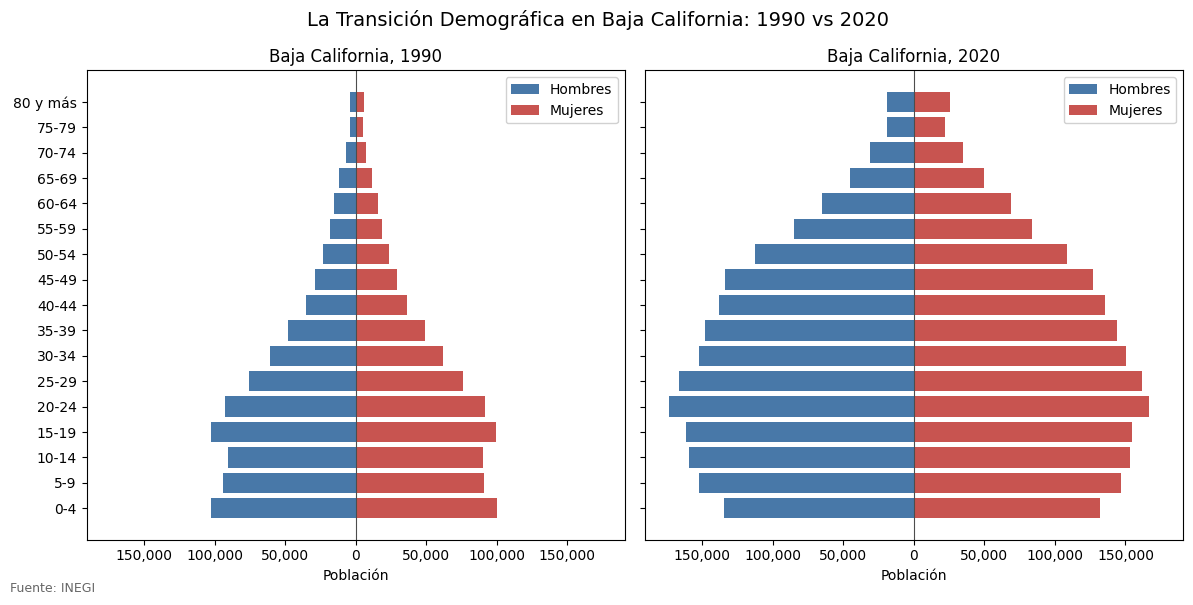

In [8]:
# TODO 1.1: carga tus datos de 1990 y 2020 (pd.read_csv / read_excel; encoding='latin-1' si hace falta)

import matplotlib.ticker as mticker
pob_df = pd.read_excel('Baja California_JDHZ_LACD.xlsx', sheet_name='Tabulado', header=[5, 6])

pob_df.columns = ['entidad', 'grupo'] + [f'{año}_{sexo.lower()}' for año, sexo in pob_df.columns[2:]]
pob_df = pob_df[pob_df['entidad'] == 'Baja California'].copy()
pob_df = pob_df[~pob_df['grupo'].isin(['Total', 'No especificado'])].reset_index(drop=True)

abiertos = ['80 a 84 años', '85 a 89 años', '90 a 94 años', '95 a 99 años', '100 años y más']
def preparar_piramide(año):
    d = pob_df[['grupo', f'{año}_hombres', f'{año}_mujeres', f'{año}_total']].copy()
    d.columns = ['grupo', 'hombres', 'mujeres', 'total']
    cerrados = d[~d['grupo'].isin(abiertos)].copy()
    suma_80 = d[d['grupo'].isin(abiertos)][['hombres', 'mujeres', 'total']].sum()
    fila_80 = pd.DataFrame([{'grupo': '80 y más', 'hombres': suma_80['hombres'], 'mujeres': suma_80['mujeres'], 'total': suma_80['total']}])
    out = pd.concat([cerrados, fila_80], ignore_index=True)
    out['grupo'] = out['grupo'].str.replace(' a ', '-').str.replace(' años', '')
    return out

pop_1990 = preparar_piramide(1990)
pop_2020 = preparar_piramide(2020)

# TODO 1.2: construye las dos pirámides lado a lado con fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# - hombres a la izquierda (valores negativos), mujeres a la derecha
# - mismo xlim en ambas; título con estado y año; fuente citada en el pie

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

def dibujar_piramide(ax, df, titulo):
    ax.barh(df['grupo'], -df['hombres'], color='#4878a8', label='Hombres')
    ax.barh(df['grupo'], df['mujeres'], color='#c85450', label='Mujeres')
    ax.axvline(0, color='0.3', lw=0.8)
    ax.set_xlabel('Población')
    ax.set_title(titulo)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{abs(int(x)):,}'))
    ax.legend(loc='upper right', framealpha=0.9)

dibujar_piramide(ax1, pop_1990, 'Baja California, 1990')
dibujar_piramide(ax2, pop_2020, 'Baja California, 2020')

limite = max(pop_2020['hombres'].max(), pop_2020['mujeres'].max()) * 1.1
ax1.set_xlim(-limite, limite)
ax2.set_xlim(-limite, limite)

fig.suptitle('La Transición Demográfica en Baja California: 1990 vs 2020', fontsize=14)
fig.text(0.01, 0.01, 'Fuente: INEGI', fontsize=9, color='0.4')
plt.tight_layout()
plt.show()

# TODO 1.3 (interpretación, en este comentario):
#  (a) ¿Qué le pasó a la base (0-14) entre 1990 y 2020? ¿Qué fenómeno demográfico lo explica?
# Se estrechó, primordialmente por la pérdida de fecundidad y natalidad. Como parte de la transición demográfica, las familias bajacalifornianas
# pasaron a tener menos hijos, lo que redujo el ingreso de nuevas generaciones a la base.
#  (b) ¿Dónde está hoy la generación que era la base en 1990? (pista: notas §3 — viajó por su diagonal de Lexis)
# En sus 30´s. Esta generación conforma en 2020 los grupos de edad de 30 a 44 años. Hoy representan el sector más abultado en el centro de la
# pirámide, concentrando el grueso de la fuerza laboral y reproductiva.
#  (c) ¿Ves alguna asimetría hombres/mujeres en edades 20-40? ¿Qué fenómeno podría explicarla en TU estado?
# Es común notar irregularidades o un ligero exceso de población en el lado masculino dentro de las edades productivas, rompiendo la simetría
# perfecta con el lado de las mujeres. La causa esencial es la migración, puesto que la maquila y la agricultura son sectores de mayor atractivo
# para hombres en edad productiva. La sobremortalidad del demográfico masculino por causas externas relacionadas
# con violencia e inseguridad choca con esa asimetría.

## Parte 2 — Las tasas brutas de tu estado (notas §1)

Replica el Ejemplo 1 de las notas con datos reales de tu entidad: usa como $\bar{N}$ la población a mitad de año (CONAPO) o el promedio de dos años consecutivos.

In [9]:
# Valores nacionales de referencia (cifras redondeadas ~2020, para validar tu orden de magnitud):
REF_NACIONAL = {'TBN_pormil': 15.8, 'TBM_pormil': 5.9, 'r_pormil': 9.5}

# TODO 2.1: define B, D y Nbar de tu estado con tus datos descargados y calcula:
#   TBN, TBM (por mil), r (por mil) y t2 = ln(2)/r (en años)
# Nbar: Población total de Baja California en 2020
Nbar = pop_2020['total'].sum()  # 3,760,801

B = 58506

D = 22934

TBN = (B / Nbar) * 1000
TBM = (D / Nbar) * 1000
r = (B - D) / Nbar
t2 = np.log(2) / r

print(f"Población media (Nbar): {Nbar:,.0f}")
print(f"Nacimientos (B): {B:,}")
print(f"Defunciones (D): {D:,}")
print(f"Tasa Bruta de Natalidad (TBN): {TBN:.2f} por mil")
print(f"Tasa Bruta de Mortalidad (TBM): {TBM:.2f} por mil")
print(f"Tasa de Crecimiento Natural (r): {r*1000:.2f} por mil")
print(f"Tiempo de duplicación (t2): {t2:.1f} años")

# TODO 2.2 (interpretación): ¿tu estado crece más rápido o más lento que el país?
# ¿El componente migratorio de tu estado es positivo o negativo? (CONAPO publica el saldo)
# ¿Qué tan creíble es t2 como pronóstico? ¿Qué supuesto fuerte hace? (notas §1, Ejemplo 1)

#A nivel natural ($9.46$‰), Baja California crece a un ritmo casi idéntico al promedio nacional ($9.5$‰).
#Sin embargo, como el saldo migratorio del estado es fuertemente positivo, su crecimiento total real es mucho más acelerado.
#Es poco creíble como pronóstico exacto. El cálculo de $t_2$ hace el supuesto fuerte de que la tasa de crecimiento se mantendrá constante,
#lo cual ignora la transición demográfica (caída de fecundidad y aumento de mortalidad por envejecimiento) y la volatilidad de la migración.


Población media (Nbar): 3,760,801
Nacimientos (B): 58,506
Defunciones (D): 22,934
Tasa Bruta de Natalidad (TBN): 15.56 por mil
Tasa Bruta de Mortalidad (TBM): 6.10 por mil
Tasa de Crecimiento Natural (r): 9.46 por mil
Tiempo de duplicación (t2): 73.3 años


## Parte 3 — La curva de mortalidad de tu estado (notas §2)

Primero reproducimos la curva ilustrativa de las notas para que veas el patrón; después construyes la de tu estado.

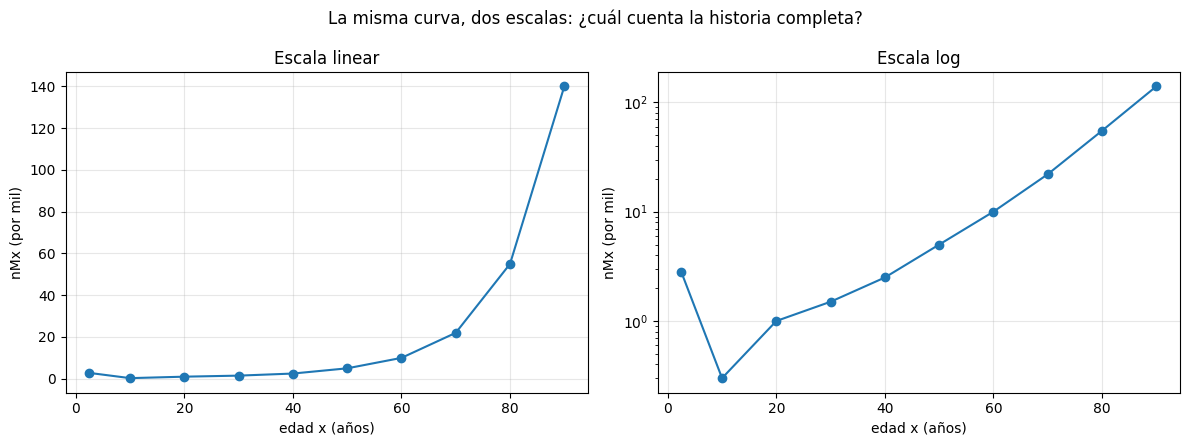

In [10]:
# Curva ilustrativa de las notas (§2, Ejemplo 2) — cifras por mil, orden de magnitud nacional
edades_medias = [2.5, 10, 20, 30, 40, 50, 60, 70, 80, 90]
nmx_ilustrativa = [2.8, 0.3, 1.0, 1.5, 2.5, 5, 10, 22, 55, 140]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, escala in [(ax1, 'linear'), (ax2, 'log')]:
    ax.plot(edades_medias, nmx_ilustrativa, 'o-')
    ax.set_yscale(escala)
    ax.set_xlabel('edad x (años)')
    ax.set_ylabel('nMx (por mil)')
    ax.set_title(f'Escala {escala}')
    ax.grid(alpha=0.3)
plt.suptitle('La misma curva, dos escalas: ¿cuál cuenta la historia completa?')
plt.tight_layout()
plt.show()

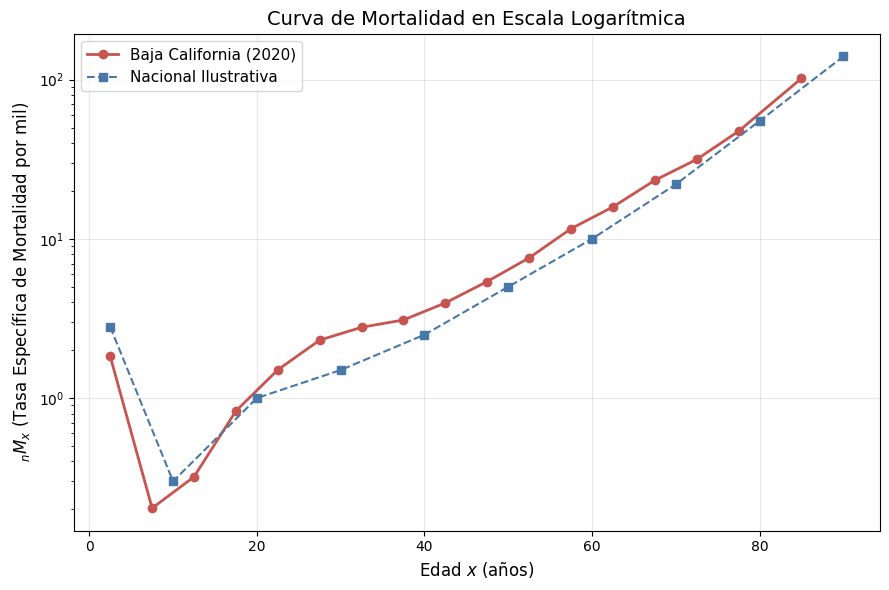

In [11]:
# TODO 3.1: construye las nMx de TU estado:
#   nMx = defunciones del grupo de edad / población a mitad de año del grupo (x 1000)
# Usa los grupos de edad que traigan tus datos de defunciones (típicamente quinquenales).

def_df = pd.read_excel('INEGI_exporta_20_8_2026_15_5_47.xls', skiprows=4)
def_df.columns = ['grupo', 'total', 'hombres', 'mujeres', 'ne']
def_df = def_df.dropna(subset=['grupo']).reset_index(drop=True)
def_df['total'] = pd.to_numeric(def_df['total'].astype(str).str.replace(',', ''), errors='coerce')

d_0_4 = def_df.loc[def_df['grupo'].isin(['Menores de 1 año', '1-4 años']), 'total'].sum()
d_80_plus = def_df.loc[def_df['grupo'].isin(['80-84 años', '85 años y más']), 'total'].sum()

grupos_nMx = ['0-4']
nMx_vals = [(d_0_4 / pop_2020.loc[0, 'total']) * 1000]

for i in range(1, 16):
    grupo_pop = pop_2020.loc[i, 'grupo']
    grupo_def = f"{grupo_pop} años"
    d_val = def_df.loc[def_df['grupo'] == grupo_def, 'total'].values[0]
    p_val = pop_2020.loc[i, 'total']

    grupos_nMx.append(grupo_pop)
    nMx_vals.append((d_val / p_val) * 1000)

grupos_nMx.append('80+')
nMx_vals.append((d_80_plus / pop_2020.loc[16, 'total']) * 1000)

# TODO 3.2: grafica tu curva en escala log, encimada con la ilustrativa nacional para comparar
edades_medias = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67.5, 72.5, 77.5, 85]
edades_nacional = [2.5, 10, 20, 30, 40, 50, 60, 70, 80, 90]
nmx_nacional = [2.8, 0.3, 1.0, 1.5, 2.5, 5, 10, 22, 55, 140]

plt.figure(figsize=(9, 6))
plt.plot(edades_medias, nMx_vals, 'o-', color='#c85450', lw=2, label='Baja California (2020)')
plt.plot(edades_nacional, nmx_nacional, 's--', color='#4878a8', lw=1.5, label='Nacional Ilustrativa')

plt.yscale('log')
plt.xlabel('Edad $x$ (años)', fontsize=12)
plt.ylabel('$_nM_x$ (Tasa Específica de Mortalidad por mil)', fontsize=12)
plt.title('Curva de Mortalidad en Escala Logarítmica', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# TODO 3.3 (interpretación): ¿tu estado tiene la 'joroba' de adultos jóvenes (15-35)?
# ¿Es más o menos pronunciada que la referencia? ¿Qué hipótesis propones para TU estado?
# ¿En qué edades tu estado se separa más de la curva nacional?

#Sí, es una joroba muy evidente.
#Es mucho más pronunciada que la curva ilustrativa nacional. La hipótesis principal es una mayor incidencia de causas de muerte
#externas (homicidios, accidentes de tráfico y violencia) que afectan mayormente a los hombres jóvenes, una característica
#común en las fronteras.
#La mayor separación está en el rango de los 20 a los 45 años y nuevamente en las edades de 60 a 75 años, donde la mortalidad
#bajacaliforniana supera a la referencia.


## Parte 4 — La trampa de las brutas, con tu estado (notas §5)

Ahora que tienes la TBM de tu estado (Parte 2) y su estructura (Parte 1), enfrenta la pregunta que motiva la estandarización de la semana 4.

In [12]:
# TODO 4.1: calcula el % de población de 60+ de tu estado en 2020 y compáralo con el nacional
# (nacional 2020: aproximadamente 11%).

pop_60_plus = pop_2020.loc[12:, 'total'].sum()
pct_60_plus = (pop_60_plus / Nbar) * 100

print(f"Población 60+ en Baja California: {pop_60_plus:,.0f} personas")
print(f"Porcentaje de 60+ en Baja California: {pct_60_plus:.2f}%")
print("Porcentaje 60+ a nivel Nacional: ~11.00%")

# TODO 4.2 (la pregunta central, responde en este comentario con tus números):
#  Tu TBM salió [mayor/menor] que la nacional. A la luz del Ejemplo 4 de las notas (§5):
#  ¿puedes concluir que en tu estado 'se muere más/menos' que en el país? ¿Por qué no basta la TBM?
#  ¿Qué evidencia de tu Parte 3 (las tasas específicas) matiza o contradice a la bruta?

#La TBM salió mayor que la nacional.
#La TBM no basta para sacar conclusiones definitivas porque es un promedio ponderado influenciado por la estructura de edad.
#Un estado envejecido puede tener una TBM alta aunque su sistema de salud sea excelente.

# TODO 4.3 (reto, opcional): calcula qué TBM tendría tu estado si mantuviera SUS tasas específicas
# pero con la estructura por edad NACIONAL (suma de nMx * proporción nacional del grupo).
# Acabas de hacer tu primera estandarización directa — te adelantaste a la semana 4.

#Baja California es más joven que el país en su cúspide (10.09% de 60+ vs 11%), lo cual, en teoría,
#debería bajar su TBM. Sin embargo, la TBM es más alta. Al revisar las tasas específicas,
#se muere más a edades tempranas y medias. En este caso, la TBM no mintió por estructura envejecida, sino que las altas tasas específicas
#reales empujaron el promedio general hacia arriba.


Población 60+ en Baja California: 379,302 personas
Porcentaje de 60+ en Baja California: 10.09%
Porcentaje 60+ a nivel Nacional: ~11.00%


## Cierre y entrega

**Checklist:**
- [ ] Pirámides 1990/2020 con mismo eje, título y fuente; interpretación (1.3) escrita.
- [ ] TBN, TBM, r, t₂ de tu estado, comparados contra la referencia nacional.
- [ ] Curva ₙMₓ de tu estado en escala log, encimada con la referencia; interpretación (3.3).
- [ ] Respuesta razonada de 4.2 — es el insumo directo de tu **Entrega 1** (semana 7).
- [ ] El notebook corre completo de arriba a abajo (Entorno de ejecución → Reiniciar y ejecutar todo).

**Para la semana 3:** lectura de Preston cap. 3 (primera mitad): construiremos la **tabla de vida** — la máquina que convierte las ₙMₓ que acabas de calcular en probabilidades de muerte y esperanza de vida.
---

## ⚠ Cómo se entrega: el ARCHIVO, no el enlace

**No compartas el enlace de Colab.** El sistema necesita el archivo, y hay dos
razones de fondo:

1. Un enlace apunta a un notebook que **sigue siendo tuyo y sigue cambiando**.
   No hay una versión que calificar: lo que el profesor abra mañana puede no ser
   lo que entregaste hoy.
2. La retroalimentación automática necesita leer el archivo. Con un enlace no
   recibes nada.

Los tres pasos, en Colab:

1. **Archivo** → **Descargar** → **Descargar .ipynb**
2. Ve a la página de la actividad en el sistema.
3. Arrastra el `.ipynb` a la zona de subida y presiona **Entregar notebook**.

Al subirlo recibes en menos de un minuto tus puntos por sección y una
orientación para mejorarlos, y **te queda un segundo intento** para corregir.

